# Checkpoint Results

This notebook inspects the current `Challenge3.py` checkpoint layout.
It loads a Challenge 3 NSGA-II checkpoint, plots the Pareto front, runs the same checkpoint evaluation helper used by the script, and saves the Pareto plot plus morphology CSV.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from Challenge3 import evaluate_checkpoint, save_morphology_csv, save_pareto_front
from evorob.utils.filesys import get_last_checkpoint_dir

In [2]:
# Change these to inspect different runs
RESULTS_DIR = Path("results/AntHill-v0/multi_19h30")
CHECKPOINT = "98"  # either "latest" or a specific generation number
N_EPISODES = 8          # use a small number for quick progress checks
OUTPUT_SUBDIR = "progress_eval"

In [3]:
assert RESULTS_DIR.exists(), f"Missing results directory: {RESULTS_DIR}"

if CHECKPOINT == "latest":
    checkpoint_root = RESULTS_DIR
    latest_checkpoint = Path(get_last_checkpoint_dir(str(RESULTS_DIR)))
else:
    latest_checkpoint = RESULTS_DIR / str(CHECKPOINT)
    checkpoint_root = latest_checkpoint

assert latest_checkpoint.exists(), f"Missing checkpoint directory: {latest_checkpoint}"

x_path = latest_checkpoint / "x.npy"
f_path = latest_checkpoint / "f.npy"
x_best_path = latest_checkpoint / "x_best.npy"

population = np.load(x_path, allow_pickle=True)
fitness = np.load(f_path, allow_pickle=True)
x_best = np.load(x_best_path, allow_pickle=True)

print(f"Checkpoint root: {checkpoint_root}")
print(f"Checkpoint folder: {latest_checkpoint}")
print(f"population shape: {population.shape}")
print(f"fitness shape: {fitness.shape}")
print(f"x_best shape: {x_best.shape}")
if fitness.ndim == 2 and fitness.shape[1] >= 2:
    print(f"obj1 range: {fitness[:, 0].min():.3f} .. {fitness[:, 0].max():.3f}")
    print(f"obj2 range: {fitness[:, 1].min():.3f} .. {fitness[:, 1].max():.3f}")

Checkpoint root: results/AntHill-v0/multi_19h30/98
Checkpoint folder: results/AntHill-v0/multi_19h30/98
population shape: (80, 288)
fitness shape: (80, 2)
x_best shape: (288,)
obj1 range: 266.422 .. 553.798
obj2 range: -5.469 .. -0.004


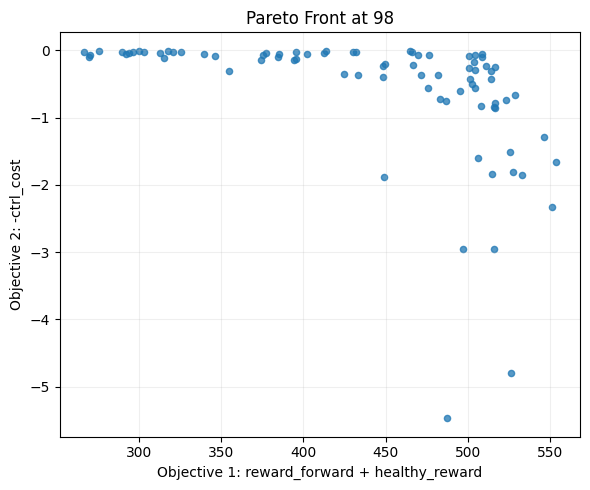

In [4]:
if fitness.ndim == 2 and fitness.shape[1] >= 2:
    plt.figure(figsize=(6, 5))
    plt.scatter(fitness[:, 0], fitness[:, 1], s=20, alpha=0.75)
    plt.xlabel("Objective 1: reward_forward + healthy_reward")
    plt.ylabel("Objective 2: -ctrl_cost")
    plt.title(f"Pareto Front at {latest_checkpoint.name}")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("Fitness is not multi-objective; cannot plot Pareto front.")

In [5]:
eval_dir = latest_checkpoint / OUTPUT_SUBDIR
results = evaluate_checkpoint(
    checkpoint_dir=str(checkpoint_root),
    output_dir=str(eval_dir),
    n_episodes=N_EPISODES,
)
pareto_path = save_pareto_front(
    checkpoint_dir=str(checkpoint_root),
    output_dir=str(eval_dir),
)
morphology_path = save_morphology_csv(
    checkpoint_dir=str(checkpoint_root),
    output_dir=str(eval_dir),
)
results

No checkpoint directories found in results/AntHill-v0/multi_19h30/98.
Loaded x_best  (shape: (288,))
Specialist obj1 (forward+healthy): idx=64  f=[553.7983425   -1.66536989]
Specialist obj2 (efficiency)     : idx=63  f=[ 3.1763856e+02 -4.1375339e-03]
Generalist (best sum)    : idx=64    f=[553.7983425   -1.66536989]
Controller: NeuralNetworkController  |  params=280  |  genotype size=288

Evaluating specialist_obj1 (8 episodes)...
  reward: 2935.26 +/- 199.09  obj1: 1063.96  obj2: -2.73
Evaluating specialist_obj2 (8 episodes)...
  reward: 347.20 +/- 107.05  obj1: 337.69  obj2: -0.00
Evaluating generalist (8 episodes)...
  reward: 2935.26 +/- 199.09  obj1: 1063.96  obj2: -2.73
  Video saved: results/AntHill-v0/multi_19h30/98/progress_eval/evaluation_specialist_forward.mp4
  Video saved: results/AntHill-v0/multi_19h30/98/progress_eval/evaluation_specialist_efficiency.mp4
  Video saved: results/AntHill-v0/multi_19h30/98/progress_eval/evaluation_generalist.mp4

Score saved to: results/AntH

{'specialist_obj1': {'reward': {'values': [3129.0292118170323,
    3152.5113914649114,
    2781.596622491767,
    2947.1861937817107,
    2753.257153536264,
    3024.3463185394135,
    2571.4014196524677,
    3122.728197072214],
   'mean': 2935.2570635444727,
   'std': 199.0911040942829,
   'best': 3152.5113914649114,
   'worst': 2571.4014196524677,
   'median': 2985.766256160562},
  'obj1': {'values': [1074.5748493865708,
    1085.3403812295796,
    1058.653791762398,
    1045.0497567752489,
    1053.348284043193,
    1083.7818373320385,
    1047.6577528624282,
    1063.254453459471],
   'mean': 1063.957638356366,
   'std': 14.69406188526496,
   'best': 1085.3403812295796,
   'worst': 1045.0497567752489,
   'median': 1060.9541226109345},
  'obj2': {'values': [-2.8805123642852357,
    -3.380352247008946,
    -2.072266072603169,
    -3.143216674224468,
    -2.5876404860657343,
    -3.0689255963746023,
    -1.8429175848142383,
    -2.8280906853227306],
   'mean': -2.7254902138373907,
   

In [6]:
score_path = eval_dir / "evaluation_score.txt"
print(f"score file: {score_path}")
print(f"pareto plot: {pareto_path}")
print(f"morphology csv: {morphology_path}")

if score_path.exists():
    print(score_path.read_text())
else:
    print(f"No score file found at {score_path}")

score file: results/AntHill-v0/multi_19h30/98/progress_eval/evaluation_score.txt
pareto plot: None
morphology csv: None
MICRO-515 Challenge 3 - Evaluation Results

Controller      : NeuralNetworkController (280 params)
Genotype size   : 288  (weights=280, body=8)
Checkpoint      : results/AntHill-v0/multi_19h30/98
Episodes/indiv. : 8
Neutral reward  : healthy_reward + x_position - ctrl_cost - cfrc_cost (from info)
Objectives      : [reward_forward+healthy_reward, -ctrl_cost]

SUMMARY
Individual              Rew.Mean  Rew.Std  Rew.Best  Obj1.Mean  Obj2.Mean
------------------------------------------------------------------------
specialist_obj1          2935.26   199.09   3152.51    1063.96      -2.73
specialist_obj2           347.20   107.05    558.05     337.69      -0.00
generalist               2935.26   199.09   3152.51    1063.96      -2.73

--------------------------------------------------
SPECIALIST_OBJ1 — Per-episode rewards
--------------------------------------------------
 